# Explore Autoregressive Methods on TiRex

In [1]:
import sys
sys.path.append('../tirex/src') # Add the path to the tirex module

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
from tqdm import tqdm

from tirex import ForecastModel, load_model
from tirex.util import plot_forecast

# set default figure size for all plots
plt.rcParams["figure.figsize"] = (12, 6)

# Load data

Download the data from the notebook [data_download.ipynb](data_download.ipynb) before.

In [3]:
data_path_train = "../data/train.csv"
data_path_test = "../data/test.csv"
data_test = pl.read_csv(data_path_test, try_parse_dates=True)

number_series = len(data_test['series_index'].unique())
print(f"Number of time series in the test set: {number_series}")
data_test.head()

Number of time series in the test set: 361


timestamp,value,series_name,series_index
datetime[μs],f64,str,i64
2025-09-27 22:00:00,0.564,"""home_electricity""",0
2025-09-27 22:15:00,0.564,"""home_electricity""",0
2025-09-27 22:30:00,0.556,"""home_electricity""",0
2025-09-27 22:45:00,0.568,"""home_electricity""",0
2025-09-27 23:00:00,0.56,"""home_electricity""",0


# Load Model

In [4]:
model: ForecastModel = load_model("NX-AI/TiRex")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {total_params:,}")

Total Parameters: 35,291,200


In [5]:
# for restoring the original behavior of the model after our modifications
from tirex import TiRexZero

TiRexZero._original_forecast_tensor = TiRexZero._forecast_tensor

def restore_original_behavior():
    if hasattr(TiRexZero, '_original_forecast_tensor'):
        TiRexZero._forecast_tensor = TiRexZero._original_forecast_tensor
        print("Restored original NaN-filling behavior.")
    else:
        print("Original method backup not found.")

# Problem definition

Selected time series HU_solar_generation_actual_15 with index 50 and shape (7172,)


<Axes: >

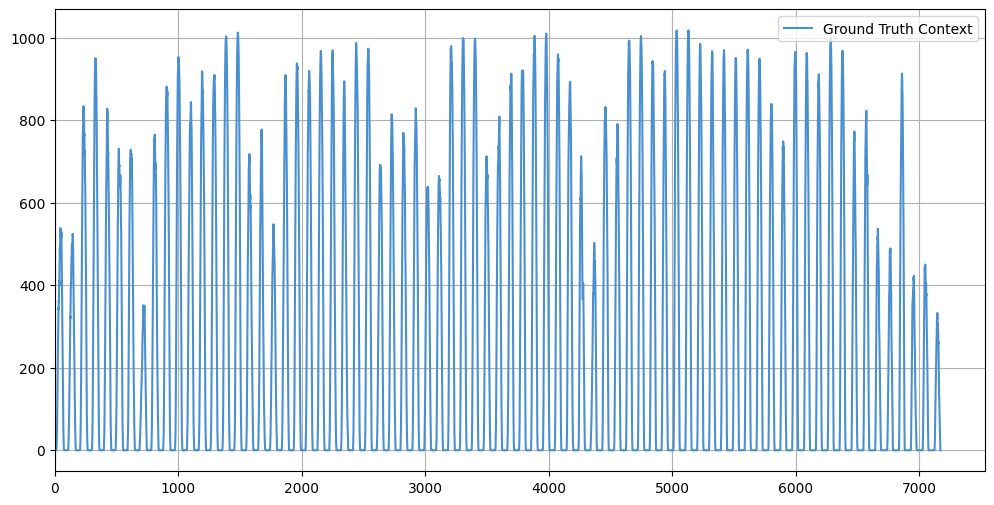

In [6]:
# select a single time series from the test data
idx_s = 50

df_s = data_test.filter(pl.col("series_index") == idx_s)
name_s = df_s.select(pl.col("series_name"))[0].item()
values_s = df_s.select(pl.col("value")).to_numpy().copy().reshape(-1) # copy to make it writeable for the model
print(f"Selected time series {name_s} with index {idx_s} and shape {values_s.shape}")
plot_forecast(values_s)

In [7]:
# set prediction length and starting point for prediction
prediction_length = 2200
start_point = 2048 # full context of the model is 2048

ctx_s, future_s = np.split(values_s, [start_point])
ctx_s.shape, future_s.shape

((2048,), (5124,))

In [8]:
restore_original_behavior()
quantiles, mean = model.forecast(torch.as_tensor(ctx_s), prediction_length=prediction_length)

Restored original NaN-filling behavior.


Prefix: Original | idx: 50 | Feature: 0 | SMAPE: 1.1696 | MASE: 7.1709 | r2: 0.5932 | WIS: 274.6923


array([[0.21181818, 0.35045455, 0.40772727, 0.455     , 0.53227273,
        0.65636364, 0.73454545, 0.79772727, 0.89636364]])

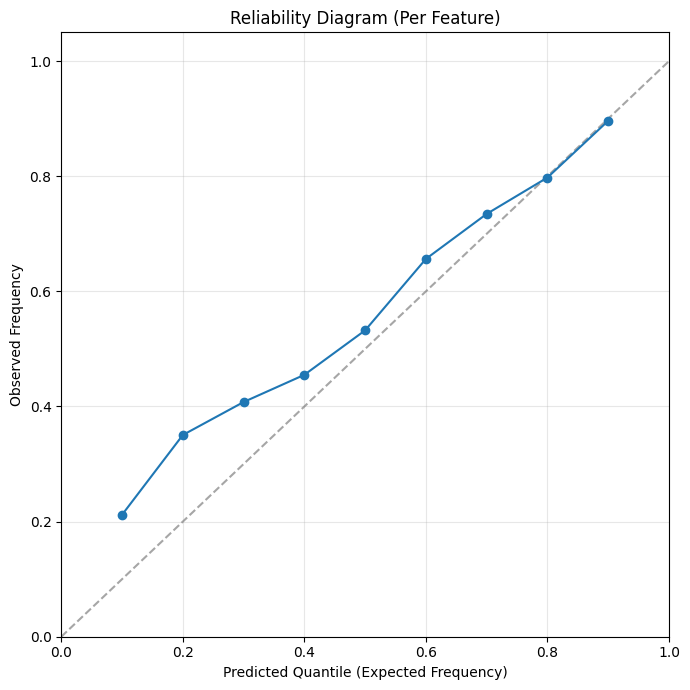

In [96]:
import tirex_loss
from tirex_loss.evaluation.metrics import score_data, calculate_quantile_reliability
import importlib
importlib.reload(tirex_loss.evaluation.metrics)

# change shape to (n_samples, n_outputs)
y_pred = quantiles.cpu().numpy().transpose(1, 0, 2)
y_true = future_s[:prediction_length].reshape(-1, 1)
y_train = ctx_s.reshape(-1, 1)

# y_mean_pred = np.array([1, 2, 3, 1]).reshape(-1, 1) # dummy data
# y_true = np.array([1, 2, 3, 1]).reshape(-1, 1) # dummy data
# y_train = np.array([1, 2, 3, 1]).reshape(-1, 1) # dummy data

score_mape, score_mase, score_r2, score_wis = score_data(
            y_true=y_true,
            y_pred=y_pred,
            y_train=y_train,
            quantiles=model.config.quantiles,
            log_prefix=f"Original | idx: {idx_s}",
            )

calculate_quantile_reliability(y_true=y_true, y_pred=y_pred, quantiles=model.config.quantiles, plot=True)

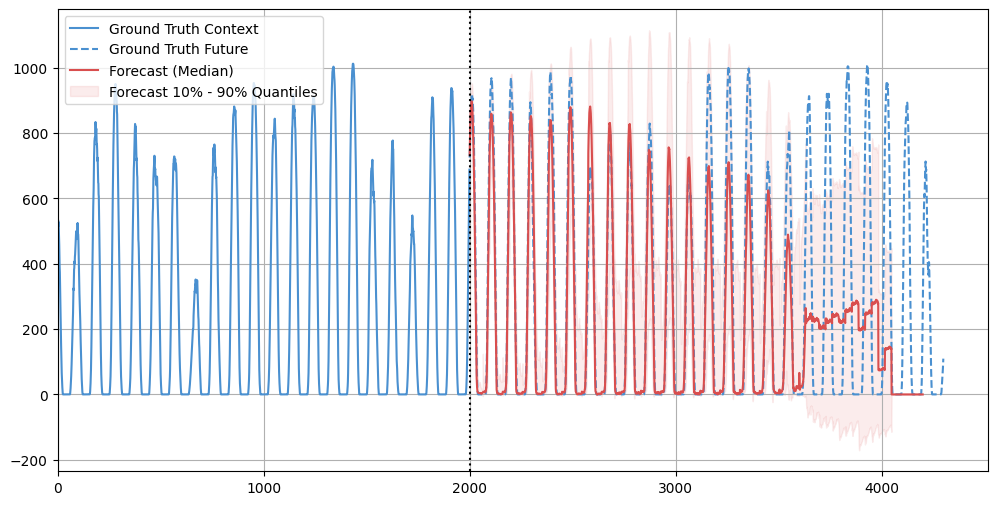

In [97]:
cap_input = -2000
cap_future = prediction_length + 100
plot_orignal_behavior = plot_forecast(ctx_s[cap_input:], quantiles.numpy()[0], future_s[:cap_future])

On the plot we can see that Tirex failes for long term forecasts. After around forecast step 1600 it failes to predict and just outputs randomness until step 2048 which is the context window of the trained model. There it just predicts zero. This is due to when Tirex predicts the next step it shifts the context and fill future values with null. So at step 2048 we have a full context of null values.

One solution to avoid this, would be to use the predicted value instead of null. So make the model autoregressive.

# Other Methods

## Autoregressive with mean

In [ ]:
# monkey patch the model to use the autoregressive mean forecast tensor instead of filling with NaNs
from tirex_loss.modifications.autoregressive import autoregressive_mean_forecast_tensor
TiRexZero._forecast_tensor = autoregressive_mean_forecast_tensor

In [99]:
quantiles, mean = model.forecast(torch.as_tensor(ctx_s), prediction_length=prediction_length)

Prefix: Autoregressive | idx: 50 | Feature: 0 | SMAPE: 1.0813 | MASE: 3.1029 | r2: 0.9382 | WIS: 358.5614


array([[0.40090909, 0.48909091, 0.55181818, 0.59136364, 0.62045455,
        0.64181818, 0.66090909, 0.69318182, 0.73681818]])

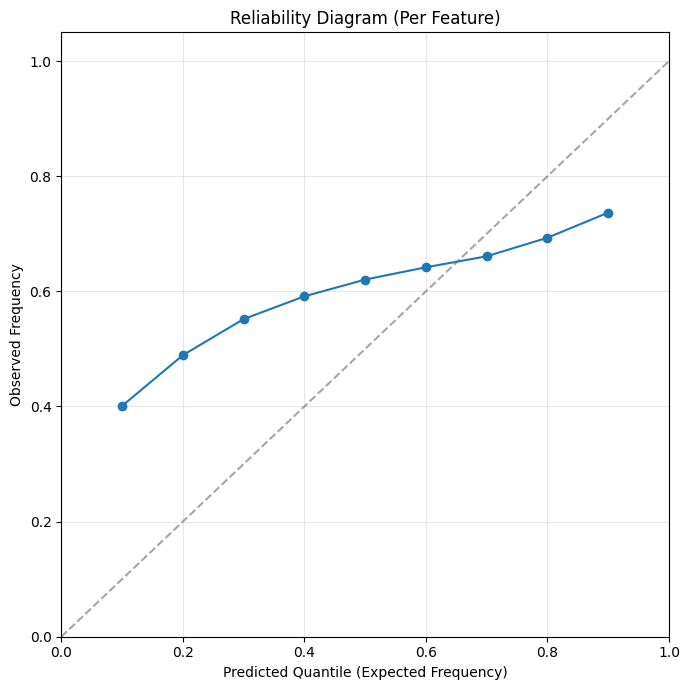

In [101]:
# change shape to (n_samples, n_outputs)
y_pred = quantiles.cpu().numpy().transpose(1, 0, 2)
y_true = future_s[:prediction_length].reshape(-1, 1)
y_train = ctx_s.reshape(-1, 1)

# scores
score_mape, score_mase, score_r2, score_wis = score_data(
            y_true=y_true,
            y_pred=y_pred,
            y_train=y_train,
            quantiles=model.config.quantiles,
            log_prefix=f"Autoregressive | idx: {idx_s}",
            )

calculate_quantile_reliability(y_true=y_true, y_pred=y_pred, quantiles=model.config.quantiles, plot=True)

<Axes: >

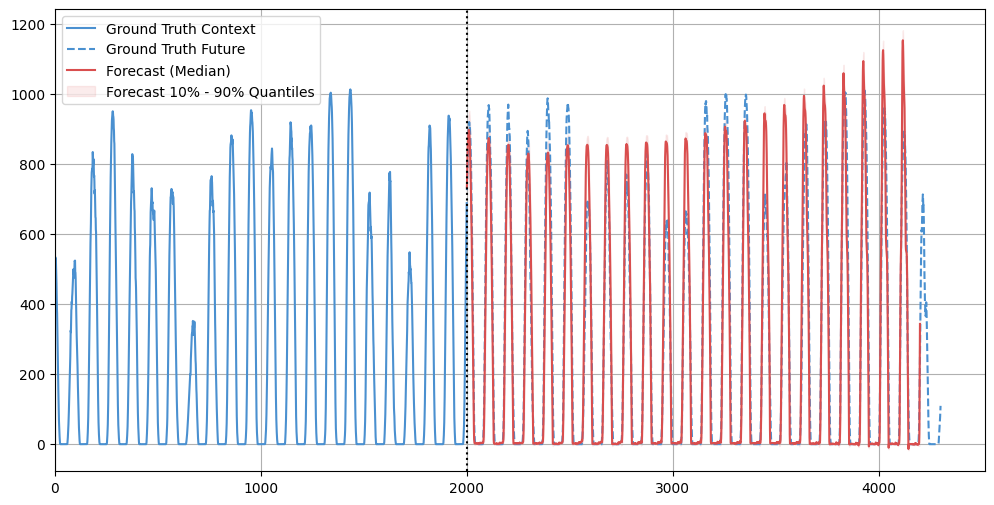

In [102]:
# plot
plot_forecast(ctx_s[cap_input:], quantiles.numpy()[0], future_s[:cap_future])

# Comparison

In [106]:
def compare_autoregressive(df_test: pl.DataFrame, prediction_length = 2200, start_point = 2048):
    scores_comparison = {"original": [], "autoregressive_mean": []}
    quantiles_comparison = {"original": [], "autoregressive_mean": []}
    mean_comparison = {"original": [], "autoregressive_mean": []}
    idx_comparison = []

    for idx_s in tqdm(df_test['series_index'].unique()):
        idx_comparison.append(idx_s)
        df_s = df_test.filter(pl.col("series_index") == idx_s)
        name_s = df_s.select(pl.col("series_name"))[0].item()
        values_s = df_s.select(pl.col("value")).to_numpy().copy().reshape(-1) # copy to make it writeable for the model

        ctx_s, future_s = np.split(values_s, [start_point])
        y_true = future_s[:prediction_length].reshape(-1, 1) # for scoring
        y_train = ctx_s.reshape(-1, 1) # for scoring

        restore_original_behavior()
        quantiles_original, mean_original = model.forecast(torch.as_tensor(ctx_s), prediction_length=prediction_length)
        quantiles_comparison["original"].append(quantiles_original.cpu().numpy())
        mean_comparison["original"].append(mean_original.cpu().numpy())

        # change shape to (n_samples, n_outputs)
        y_mean_pred = quantiles_original.cpu().numpy().transpose(1, 0, 2)
        # scores
        score_mape, score_mase, score_r2, score_wis = score_data(
                    y_true=y_true,
                    y_pred=y_mean_pred,
                    y_train=y_train,
                    quantiles=model.config.quantiles,
                    log_prefix=f"Original | idx: {idx_s}",
                    )
        scores_comparison["original"].append((score_mape, score_mase, score_r2, score_wis))

        # now with autoregressive mean filling
        TiRexZero._forecast_tensor = autoregressive_mean_forecast_tensor
        quantiles_autoregressive, mean_autoregressive = model.forecast(torch.as_tensor(ctx_s), prediction_length=prediction_length)
        quantiles_comparison["autoregressive_mean"].append(quantiles_autoregressive.cpu().numpy())
        mean_comparison["autoregressive_mean"].append(mean_autoregressive.cpu().numpy())

        # change shape to (n_samples, n_outputs)
        y_mean_pred = quantiles_autoregressive.cpu().numpy().transpose(1, 0, 2)
        # scores
        score_mape, score_mase, score_r2, score_wis = score_data(
                    y_true=y_true,
                    y_pred=y_mean_pred,
                    y_train=y_train,
                    quantiles=model.config.quantiles,
                    log_prefix=f"Autoreg | idx: {idx_s}",
                    )
        scores_comparison["autoregressive_mean"].append((score_mape, score_mase, score_r2, score_wis))

    return scores_comparison, quantiles_comparison, mean_comparison, idx_comparison

In [104]:
# compare with original behavior
series_idx = data_test['series_index'].unique()
number_series = len(series_idx)

amount_to_test = 0.01
number_series_to_test = int(number_series * amount_to_test)
data_test_sampled = data_test.filter(pl.col('series_index').is_in(series_idx.sample(number_series_to_test).implode()))
print(f"Testing on {number_series_to_test} out of {number_series} series.")

Testing on 3 out of 361 series.


## Short prediction

In [107]:
prediction_length_short = 100
start_point = 2048
scores_short, quantiles_short, means_short, idxs = compare_autoregressive(
    data_test_sampled, prediction_length=prediction_length_short, start_point=start_point)

  0%|          | 0/3 [00:00<?, ?it/s]

Restored original NaN-filling behavior.
Prefix: Original | idx: 66 | Feature: 0 | SMAPE: 0.0471 | MASE: 1.6783 | r2: 0.7551 | WIS: 1078.0537


 33%|███▎      | 1/3 [00:03<00:07,  3.96s/it]

Prefix: Autoreg | idx: 66 | Feature: 0 | SMAPE: 0.0685 | MASE: 2.4546 | r2: 0.3476 | WIS: 1093.4201
Restored original NaN-filling behavior.
Prefix: Original | idx: 76 | Feature: 0 | SMAPE: 0.0511 | MASE: 1.1814 | r2: 0.7773 | WIS: 779.3121


 67%|██████▋   | 2/3 [00:07<00:03,  3.93s/it]

Prefix: Autoreg | idx: 76 | Feature: 0 | SMAPE: 0.0558 | MASE: 1.3068 | r2: 0.7273 | WIS: 782.6891
Restored original NaN-filling behavior.
Prefix: Original | idx: 305 | Feature: 0 | SMAPE: 0.0478 | MASE: 2.6586 | r2: -0.0023 | WIS: 2.1053


100%|██████████| 3/3 [00:11<00:00,  3.92s/it]

Prefix: Autoreg | idx: 305 | Feature: 0 | SMAPE: 0.0510 | MASE: 2.8363 | r2: -0.1177 | WIS: 2.2383


<Axes: title={'center': 'Autoregressive Mean Forecasting Behavior | Series idx: 76'}>

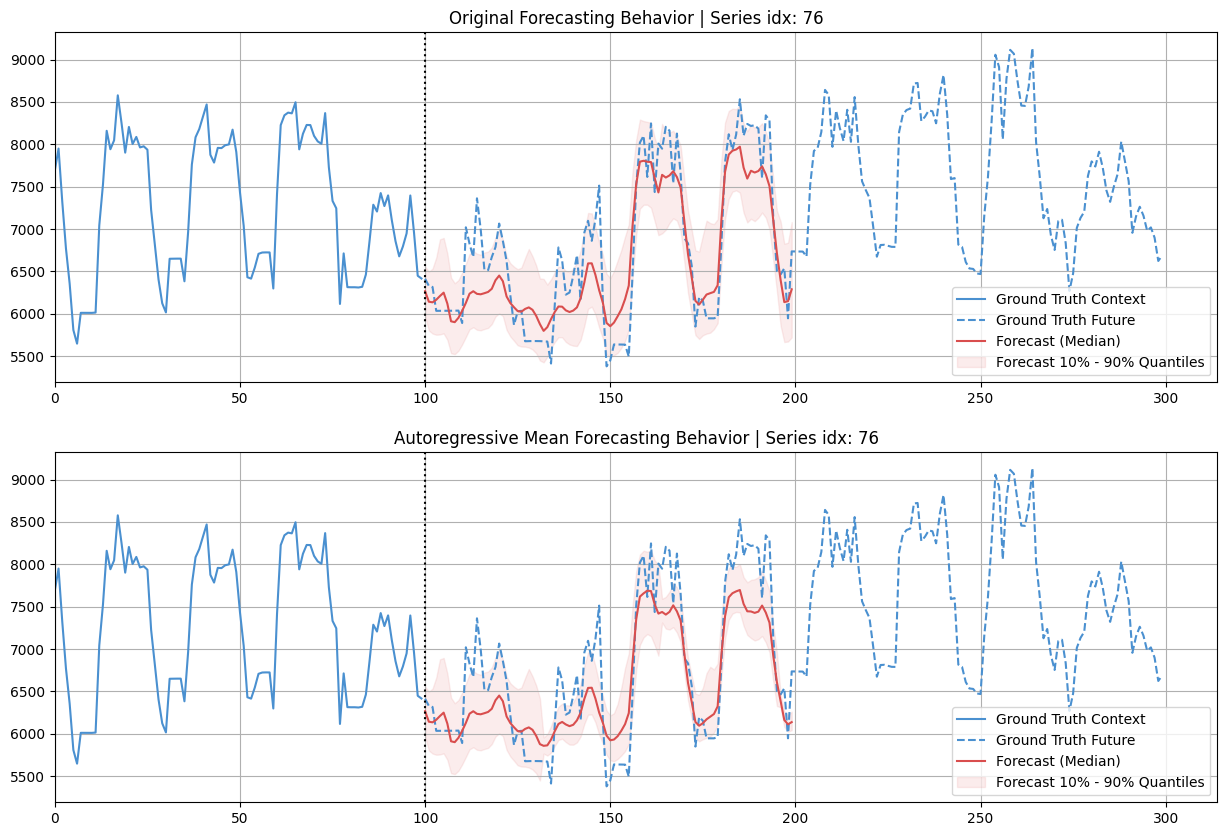

In [108]:
series_to_plot = 1

df_s = data_test.filter(pl.col("series_index") == idxs[series_to_plot])
values_s = df_s.select(pl.col("value")).to_numpy().copy().reshape(-1)
ctx_s, future_s = np.split(values_s, [start_point])

cap_input = -100
cap_future = prediction_length_short + 100
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
ax1.set_title(f"Original Forecasting Behavior | Series idx: {idxs[series_to_plot]}")
ax2.set_title(f"Autoregressive Mean Forecasting Behavior | Series idx: {idxs[series_to_plot]}")
plot_forecast(ctx_s[cap_input:], quantiles_short["original"][series_to_plot][0], future_s[:cap_future], ax=ax1)
plot_forecast(ctx_s[cap_input:], quantiles_short["autoregressive_mean"][series_to_plot][0], future_s[:cap_future], ax=ax2)

## Mid Prediction

In [109]:
prediction_length_mid = 1000
start_point = 2048
scores_mid, quantiles_mid, means_mid, idxs = compare_autoregressive(
    data_test_sampled, prediction_length=prediction_length_mid, start_point=start_point)

  0%|          | 0/3 [00:00<?, ?it/s]

Restored original NaN-filling behavior.
Prefix: Original | idx: 66 | Feature: 0 | SMAPE: 0.0859 | MASE: 3.1869 | r2: 0.4380 | WIS: 1356.6755


 33%|███▎      | 1/3 [00:31<01:02, 31.17s/it]

Prefix: Autoreg | idx: 66 | Feature: 0 | SMAPE: 0.1009 | MASE: 3.8051 | r2: 0.1481 | WIS: 1468.3023
Restored original NaN-filling behavior.
Prefix: Original | idx: 76 | Feature: 0 | SMAPE: 0.1423 | MASE: 3.6452 | r2: -0.5372 | WIS: 1109.3726


 67%|██████▋   | 2/3 [01:03<00:31, 31.57s/it]

Prefix: Autoreg | idx: 76 | Feature: 0 | SMAPE: 0.1433 | MASE: 3.7144 | r2: -0.6356 | WIS: 1204.4356
Restored original NaN-filling behavior.
Prefix: Original | idx: 305 | Feature: 0 | SMAPE: 0.1317 | MASE: 7.6729 | r2: -0.9575 | WIS: 4.6067


100%|██████████| 3/3 [01:34<00:00, 31.54s/it]

Prefix: Autoreg | idx: 305 | Feature: 0 | SMAPE: 0.1354 | MASE: 7.8914 | r2: -1.1705 | WIS: 5.3000


<Axes: title={'center': 'Autoregressive Mean Forecasting Behavior | Series idx: 66'}>

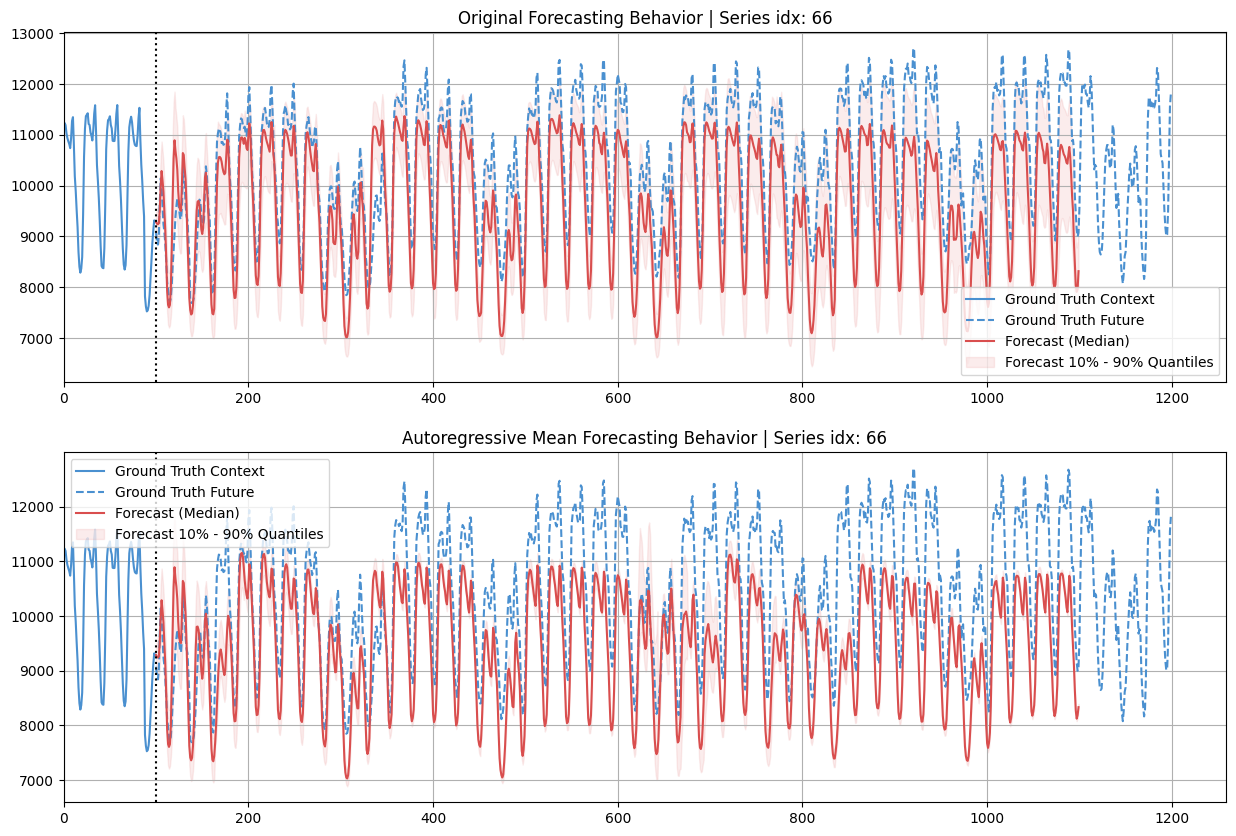

In [110]:
series_to_plot = 0

df_s = data_test.filter(pl.col("series_index") == idxs[series_to_plot])
values_s = df_s.select(pl.col("value")).to_numpy().copy().reshape(-1)
ctx_s, future_s = np.split(values_s, [start_point])

cap_input = -100
cap_future = prediction_length_mid + 100
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
ax1.set_title(f"Original Forecasting Behavior | Series idx: {idxs[series_to_plot]}")
ax2.set_title(f"Autoregressive Mean Forecasting Behavior | Series idx: {idxs[series_to_plot]}")
plot_forecast(ctx_s[cap_input:], quantiles_mid["original"][series_to_plot][0], future_s[:cap_future], ax=ax1)
plot_forecast(ctx_s[cap_input:], quantiles_mid["autoregressive_mean"][series_to_plot][0], future_s[:cap_future], ax=ax2)

## Long Prediction

In [111]:
prediction_length_long = 2200
start_point = 2048
scores_long, quantiles_long, means_long, idxs = compare_autoregressive(
    data_test_sampled, prediction_length=prediction_length_long, start_point=start_point)

  0%|          | 0/3 [00:00<?, ?it/s]

Restored original NaN-filling behavior.
Prefix: Original | idx: 66 | Feature: 0 | SMAPE: 0.2247 | MASE: 6.0202 | r2: -4.5994 | WIS: 1859.2708


 33%|███▎      | 1/3 [01:06<02:13, 66.75s/it]

Prefix: Autoreg | idx: 66 | Feature: 0 | SMAPE: 0.1012 | MASE: 3.8167 | r2: 0.1467 | WIS: 1416.4728
Restored original NaN-filling behavior.
Prefix: Original | idx: 76 | Feature: 0 | SMAPE: 0.2781 | MASE: 5.4909 | r2: -7.2887 | WIS: 1528.3623


 67%|██████▋   | 2/3 [02:13<01:06, 66.90s/it]

Prefix: Autoreg | idx: 76 | Feature: 0 | SMAPE: 0.1462 | MASE: 3.7858 | r2: -1.2551 | WIS: 1153.1150
Restored original NaN-filling behavior.
Prefix: Original | idx: 305 | Feature: 0 | SMAPE: 0.3099 | MASE: 10.5690 | r2: -0.2467 | WIS: 7.8870


100%|██████████| 3/3 [03:19<00:00, 66.56s/it]

Prefix: Autoreg | idx: 305 | Feature: 0 | SMAPE: 0.2221 | MASE: 10.8376 | r2: -0.2468 | WIS: 7.2136


<Axes: title={'center': 'Autoregressive Mean Forecasting Behavior | Series idx: 66'}>

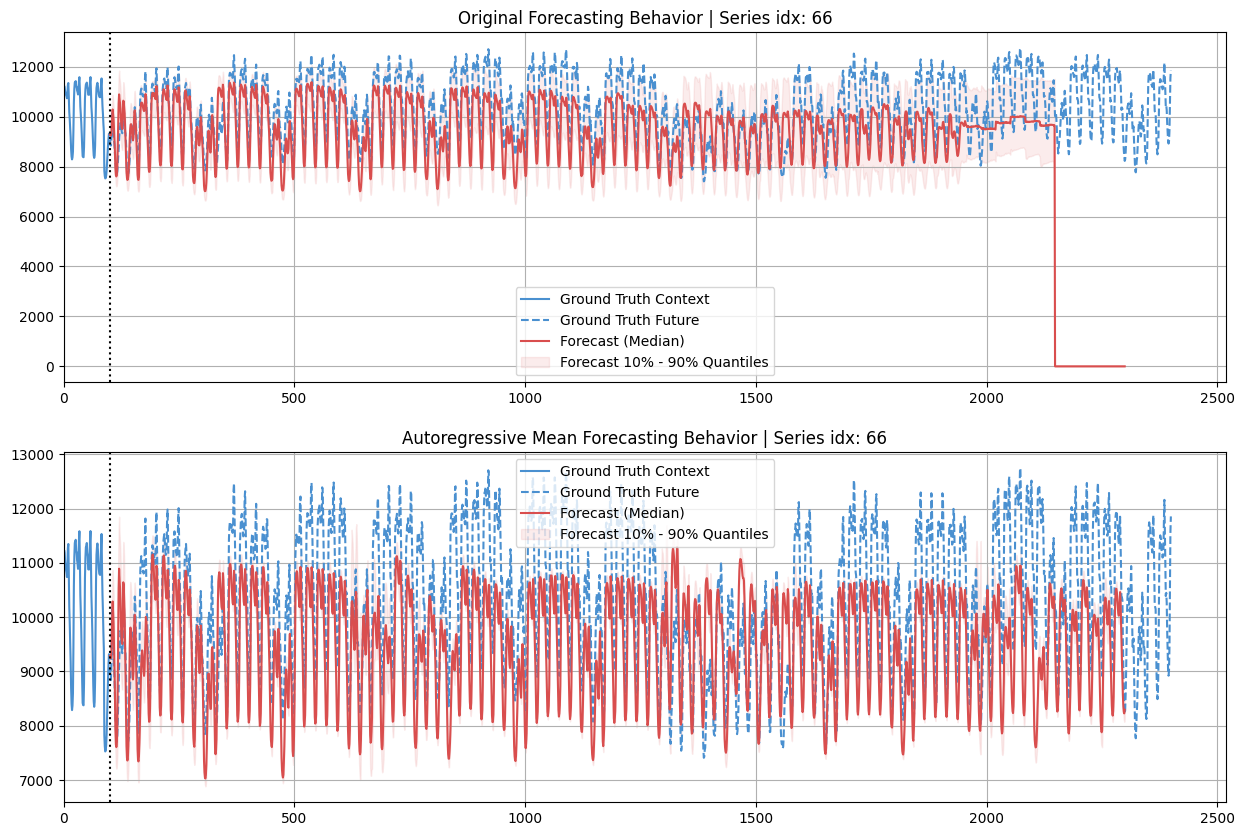

In [112]:
series_to_plot = 0

df_s = data_test.filter(pl.col("series_index") == idxs[series_to_plot])
values_s = df_s.select(pl.col("value")).to_numpy().copy().reshape(-1)
ctx_s, future_s = np.split(values_s, [start_point])

cap_input = -100
cap_future = prediction_length_long + 100
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
ax1.set_title(f"Original Forecasting Behavior | Series idx: {idxs[series_to_plot]}")
ax2.set_title(f"Autoregressive Mean Forecasting Behavior | Series idx: {idxs[series_to_plot]}")
plot_forecast(ctx_s[cap_input:], quantiles_long["original"][series_to_plot][0], future_s[:cap_future], ax=ax1)
plot_forecast(ctx_s[cap_input:], quantiles_long["autoregressive_mean"][series_to_plot][0], future_s[:cap_future], ax=ax2)